In [ ]:
#Libraries Install

In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [ ]:
#Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE

In [ ]:
#Dataset Load

In [13]:
df = pd.read_csv("C:/Users/USER/Desktop/CreditCardFraudDetection/dataset/creditcard.csv")

In [ ]:
#First 5 Records

In [14]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#Dataset Shape

In [15]:
df.shape

(284807, 31)

In [ ]:
#Dataset Info

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
#Check Null Values

In [17]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
#Data Analysis

In [21]:
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [ ]:
#Pie Chart

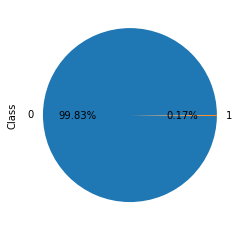

In [44]:
df['Class'].value_counts().plot.pie(
    autopct='%1.2f%%'
)
plt.show()

In [ ]:
#Bar Chart

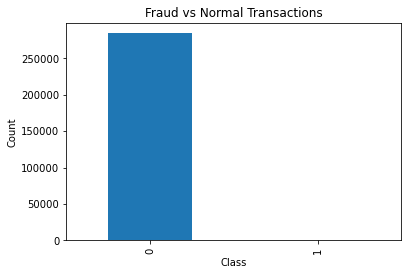

In [23]:
df['Class'].value_counts().plot(kind='bar')
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
#Feature Scaling

In [25]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(
    df[['Amount']]
)
df['Time'] = scaler.fit_transform(
    df[['Time']]
)

In [ ]:
#Features & Target

In [26]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
#Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Handle Class Imbalance Using SMOTE

In [28]:
smote = SMOTE(
    random_state=42
)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
#Check

In [29]:
y_train_smote.value_counts()

0    227451
1    227451
Name: Class, dtype: int64

In [ ]:
#Build Model

#Logistic Regression

In [30]:
model = LogisticRegression(
    max_iter=1000
)

In [ ]:
#Train

In [32]:
model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000)

In [ ]:
#Prediction

In [33]:
y_pred = model.predict(
    X_test
)

In [ ]:
#Evaluation

#Accuracy

In [34]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :",accuracy)

Accuracy : 0.9745268775675011


In [ ]:
#Precision

In [35]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision :",precision)

Precision : 0.05928338762214984


In [ ]:
#Recall

In [36]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall :",recall)

Recall : 0.9285714285714286


In [ ]:
#F1 Score

In [37]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score :",f1)

F1 Score : 0.11145131659522352


In [ ]:
#Confusion Matrix

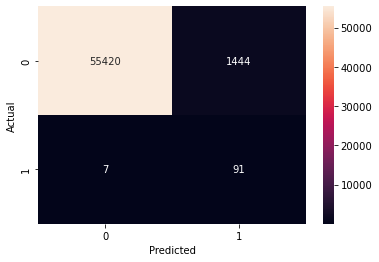

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred
)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#Save Model

In [39]:
import pickle

pickle.dump(
    model,
    open(
        "fraud_model.pkl",
        "wb"
    )
)

In [ ]:
#Classification Report

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.93      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [ ]:
#ROC-AUC Score

In [41]:
from sklearn.metrics import roc_auc_score
roc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc)

ROC AUC Score: 0.9515887531152022


In [ ]:
#ROC Curve

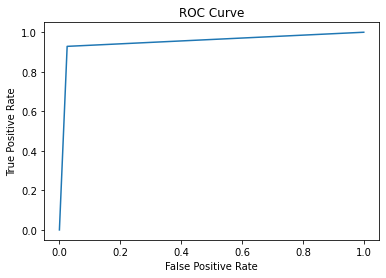

In [42]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [43]:
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.9745268775675011
Precision : 0.05928338762214984
Recall : 0.9285714285714286
F1 Score : 0.11145131659522352
